# Validación del pipeline de preparación

Este notebook tiene como finalidad verificar el funcionamiento de los componentes implementados para el pipeline de preparación del conjunto de datos OTU_2D de MMOTU.

Las pruebas realizadas en este notebook no constituyen todavía la ejecución completa del pipeline sobre el conjunto de datos.

## 1. Configuración del entorno
Se importan las librerías y se configura la ruta raiz del proyecto

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import shutil

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.pipeline.dataset import load_dataset_index
from src.pipeline.validation import (validate_dataset_index, validate_sample)
from src.pipeline.preprocessing import resize_with_padding
from src.pipeline.metadata import (build_included_record, build_exclusion_record, records_to_dataframe)
from src.pipeline.config import (PIPELINE_VALIDATION_DIR)
from src.pipeline.pipeline import (extract_technical_info, build_output_paths, prepare_row_for_metadata,run_pipeline, save_pipeline_reports)

## 2. Carga el índice del conjunto de datos

Se construye el índice a partir de los archivos originales de clasificación y partición. El índice relaciona cada identificador de imagen con su máscara binaria, partición, clase original y etiqueta binaria derivada.

In [3]:
dataset_df = load_dataset_index()

print(dataset_df.shape)
dataset_df.head()

(1469, 8)


,image_id,image_name,split,original_class,binary_label,binary_class,image_path,mask_path
0,658,658.JPG,train,5,0,benign,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...
1,384,384.JPG,train,3,0,benign,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...
2,367,367.JPG,train,3,0,benign,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...
3,730,730.JPG,train,1,0,benign,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...
4,1426,1426.JPG,train,7,1,malignant,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...


## 3. Validación general de integridad

Se ejecutan comprobaciones generales sobre el índice construido para verificar la existencia de imágenes y máscaras, la ausencia de identificadores duplicados y la separación entre las particiones de entrenamiento y validación.

In [4]:
validation_results = validate_dataset_index(dataset_df)
validation_results

{'duplicate_ids': 0,
 'missing_images': 0,
 'missing_masks': 0,
 'train_val_overlap': 0,
 'total_samples': 1469}

## 4. Validación de una muestra individual

Se selecciona una muestra del conjunto de datos para comprobar el funcionamiento de las reglas de validación implementadas: lectura correcta, dimensiones compatibles y codificación binaria válida para la máscara.

In [5]:
import cv2
import numpy as np

row = dataset_df.iloc[0]

is_valid, reason = validate_sample(row)

print("Válida:", is_valid)
print("Resultado:", reason)

Válida: True
Resultado: valid


## 5. Evaluación de una estrategia de redimensionamiento sincronizado

Como parte de la evaluación de posibles operaciones de normalización dimensional, se implementó y verificó una estrategia de redimensionamiento que preserva la relación de aspecto mediante padding. Esta prueba tiene carácter experimental y permite comprobar que una posible transformación geométrica puede aplicarse de manera sincronizada a la imagen y su máscara sin alterar la codificación binaria de esta última.

In [6]:
# Valor experimental
TEST_TARGET_SIZE = (512, 512)

In [7]:
image = cv2.imread(row["image_path"], cv2.IMREAD_COLOR)
mask = cv2.imread(row["mask_path"], cv2.IMREAD_UNCHANGED)

processed_image, processed_mask, transform_info = resize_with_padding(image, mask, target_size=TEST_TARGET_SIZE)

# 5.1 Verificación de las dimensiones y codificación
print("Imagen original:", image.shape)
print("Máscara original:", mask.shape)

print("Imagen procesada:", processed_image.shape)
print("Máscara procesada:", processed_mask.shape)
print("Valores máscara procesada:", np.unique(processed_mask))

# 5.2 Parámetros de transformación
print("\nInformación de transformación:")
for key, value in transform_info.items():
    print(f"{key}: {value}")

Imagen original: (559, 480, 3)
Máscara original: (559, 480)
Imagen procesada: (512, 512, 3)
Máscara procesada: (512, 512)
Valores máscara procesada: [0 1]

Información de transformación:
original_width: 480
original_height: 559
resized_width: 440
resized_height: 512
target_width: 512
target_height: 512
scale_factor: 0.9159212880143113
padding_left: 36
padding_right: 36
padding_top: 0
padding_bottom: 0


## 6. Inspección visual de la estrategia de redimensionamiento

Se compara visualmente la imagen y la máscara originales con sus versiones redimensionadas. Esta inspección permite comprobar que la estrategia evaluada conserva la geometría general de la muestra y mantiene la correspondencia espacial entre imagen y máscara.

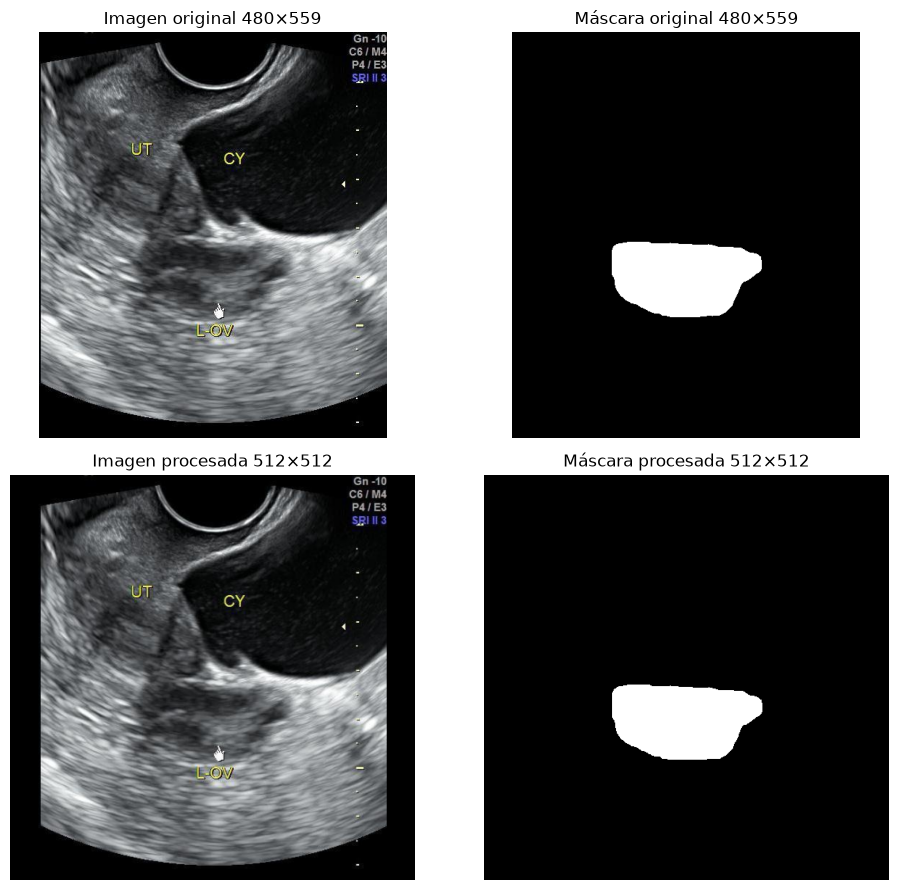

In [8]:
# Visualización del resultado
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f"Imagen original {image.shape[1]}×{image.shape[0]}")
axes[0, 0].axis("off")

axes[0, 1].imshow(mask, cmap="gray")
axes[0, 1].set_title(f"Máscara original {mask.shape[1]}×{mask.shape[0]}")
axes[0, 1].axis("off")

axes[1, 0].imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Imagen procesada 512×512")
axes[1, 0].axis("off")

axes[1, 1].imshow(processed_mask, cmap="gray")
axes[1, 1].set_title("Máscara procesada 512×512")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## 7. Verificación y registro de propiedades técnicas

Se comprueba que el pipeline pueda obtener y registrar automáticamente las propiedades técnicas de una muestra sin modificar sus archivos originales, ya que permitirá caracterizar el conjunto preparado y mantener la trazabilidad de cada imagen y su máscara asociada.

In [9]:
# 7.1 Extraer propiedades técnicas
technical_info = extract_technical_info(row)

technical_info

{'image_width': 480,
 'image_height': 559,
 'image_channels': 3,
 'image_dtype': 'uint8',
 'image_format': '.JPG',
 'mask_width': 480,
 'mask_height': 559,
 'mask_channels': 1,
 'mask_dtype': 'uint8',
 'mask_format': '.PNG',
 'mask_values': [0, 1],
 'same_dimensions': True}

In [10]:
# 7.2 Construcción de las rutas de organización
organized_image_path, organized_mask_path = build_output_paths(row=row, output_root=PIPELINE_VALIDATION_DIR,)

print("Imagen organizada:")
print(organized_image_path)

print("\nMáscara organizada:")
print(organized_mask_path)

Imagen organizada:
C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\proyecto_ia_tumores_ovaricos\data\interim\pipeline_validation\train\images\658.JPG

Máscara organizada:
C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\proyecto_ia_tumores_ovaricos\data\interim\pipeline_validation\train\masks\658_binary.PNG


In [11]:
# 7.3 Generación del registro de metadatos
metadata_row = prepare_row_for_metadata(row)

metadata_record = build_included_record(
    row=metadata_row,
    technical_info=technical_info,
    organized_image_path=organized_image_path.relative_to(PROJECT_ROOT).as_posix(),
    organized_mask_path=organized_mask_path.relative_to(PROJECT_ROOT).as_posix(),
)

metadata_test_df = records_to_dataframe([metadata_record])
metadata_test_df

,image_id,image_name,split,original_class,binary_label,binary_class,source_image_path,source_mask_path,organized_image_path,organized_mask_path,...,image_format,mask_width,mask_height,mask_channels,mask_dtype,mask_format,mask_values,same_dimensions,status,exclusion_reason
0,658,658.JPG,train,5,0,benign,data/raw/MMOTU/OTU_2D/images/658.JPG,data/raw/MMOTU/OTU_2D/annotations/658_binary.PNG,data/interim/pipeline_validation/train/images/...,data/interim/pipeline_validation/train/masks/6...,...,.JPG,480,559,1,uint8,.PNG,"0,1",True,included,


In [12]:
# Comprobación de los valores del registro de metadatos
metadata_test_df.columns.tolist()

['image_id',
 'image_name',
 'split',
 'original_class',
 'binary_label',
 'binary_class',
 'source_image_path',
 'source_mask_path',
 'organized_image_path',
 'organized_mask_path',
 'image_width',
 'image_height',
 'image_channels',
 'image_dtype',
 'image_format',
 'mask_width',
 'mask_height',
 'mask_channels',
 'mask_dtype',
 'mask_format',
 'mask_values',
 'same_dimensions',
 'status',
 'exclusion_reason']

In [13]:
# Comprobación automática de los valores del registro de metadatos
assert len(metadata_test_df) == 1
assert metadata_test_df.loc[0, "status"] == "included"
assert metadata_test_df.loc[0, "same_dimensions"]
assert metadata_test_df.loc[0, "image_channels"] == 3
assert metadata_test_df.loc[0, "mask_channels"] == 1
assert metadata_test_df.loc[0, "mask_values"] == "0,1"
assert metadata_test_df.loc[0, "exclusion_reason"] == ""

print("Registro de metadatos generado correctamente.")

Registro de metadatos generado correctamente.


## 8. Prueba del registro de exclusiones

Se verifica el mecanismo para registrar las muestras que no cumplan las condiciones establecidas por el pipeline. El propósito es comprobar que el pipeline conserva la identificación de la muestra y registra el motivo por el cual una muestra podría ser excluida durante la ejecución.

In [14]:
# Ejemplo técnico de una exclusión
metadata_row = prepare_row_for_metadata(row)
exclusion_test = build_exclusion_record(row=row, reason="test_exclusion")
exclusion_test_df = records_to_dataframe([exclusion_test])
exclusion_test_df

,image_id,image_name,split,original_class,binary_label,binary_class,source_image_path,source_mask_path,organized_image_path,organized_mask_path,...,image_format,mask_width,mask_height,mask_channels,mask_dtype,mask_format,mask_values,same_dimensions,status,exclusion_reason
0,658,658.JPG,train,5,0,benign,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\...,,,...,,None,None,None,None,,,None,excluded,test_exclusion


In [15]:
assert len(exclusion_test_df) == 1
assert exclusion_test_df.loc[0, "status"] == "excluded"
assert exclusion_test_df.loc[0, "exclusion_reason"] == "test_exclusion"
assert exclusion_test_df.loc[0, "organized_image_path"] == ""
assert exclusion_test_df.loc[0, "organized_mask_path"] == ""

print("Registro de exclusión generado correctamente.")

Registro de exclusión generado correctamente.


## 9. Evaluación experimental del redimensionamiento sobre múltiples muestras

Después de verificar la estrategia de redimensionamiento sobre una muestra individual, se realiza una prueba controlada sobre imágenes pertenecientes a ambas particiones del conjunto de datos. Su finalidad es comprobar que el redimensionamiento puede aplicarse de manera consistente a diferentes dimensiones y orientaciones, manteniendo la correspondencia entre imagen y máscara y la codificación binaria de esta última.

**Esta operación no forma parte de la preparación definitiva del conjunto de datos en esta etapa.**

In [16]:
# Visualizacion de 20 imagenes y sus mascaras
test_samples = pd.concat([
    dataset_df[
        dataset_df["split"] == "train"
    ].sample(10, random_state=42,),

    dataset_df[
        dataset_df["split"] == "validation"
    ].sample(10, random_state=42,),
])

test_results = []

for _, test_row in test_samples.iterrows():

    is_valid, reason = validate_sample(test_row)

    if not is_valid:
        test_results.append({
            "image_id": test_row["image_id"],
            "valid": False,
            "reason": reason,
        })

        continue

    image_test = cv2.imread(test_row["image_path"],cv2.IMREAD_COLOR,)
    mask_test = cv2.imread(test_row["mask_path"],cv2.IMREAD_UNCHANGED,)

    (processed_image_test, processed_mask_test, _, ) = resize_with_padding(
        image=image_test,
        mask=mask_test,
        target_size=TEST_TARGET_SIZE,
    )

    target_width, target_height = (TEST_TARGET_SIZE)

    output_ok = (
        processed_image_test.shape == (target_height, target_width, 3)
        and processed_mask_test.shape == (target_height, target_width)
        and set(np.unique(processed_mask_test).tolist()).issubset({0, 1})
    )

    test_results.append({
        "image_id": test_row["image_id"],
        "valid": output_ok,
        "reason": (
            "valid"
            if output_ok
            else "invalid_output"
        ),
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,image_id,valid,reason
0,454,True,valid
1,1178,True,valid
2,272,True,valid
3,131,True,valid
4,6,True,valid
5,251,True,valid
6,696,True,valid
7,599,True,valid
8,172,True,valid
9,1004,True,valid


In [17]:
print("Muestras procesadas correctamente:", test_results_df["valid"].sum(), "/", len(test_results_df),)

Muestras procesadas correctamente: 20 / 20


## 10. Prueba integral del pipeline definitivo

Después de verificar individualmente los componentes implementados, se realiza una prueba integral del pipeline sobre un subconjunto controlado de muestras pertenecientes a las particiones originales de entrenamiento y validación. A diferencia de la evaluación de redimensionamiento realizada anteriormente, el pipeline utilizado en esta etapa conserva las dimensiones, formatos y representación original de las imágenes y máscaras.

Las salidas se almacenan únicamente en el directorio temporal `data/interim/pipeline_validation/`.

In [18]:
# Preparación del directorio temporal
validation_dir = PIPELINE_VALIDATION_DIR.resolve()

interim_dir = (PROJECT_ROOT / "data" / "interim").resolve()
assert interim_dir in validation_dir.parents

if validation_dir.exists():
    shutil.rmtree(validation_dir)

validation_dir.mkdir(parents=True, exist_ok=True)
print("Directorio temporal preparado:", validation_dir)

Directorio temporal preparado: C:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\proyecto_ia_tumores_ovaricos\data\interim\pipeline_validation


In [19]:
# Seleccción de 6 muestras para verificar la integración del pipeline
integration_samples = pd.concat([
    dataset_df[dataset_df["split"] == "train"].sample(3, random_state=42,),
    dataset_df[dataset_df["split"] == "validation"].sample(3, random_state=42,),
])

integration_samples[
    [
        "image_id",
        "image_name",
        "split",
        "original_class",
        "binary_label",
        "binary_class",
    ]
]

,image_id,image_name,split,original_class,binary_label,binary_class
521,454,454.JPG,train,0,0,benign
737,1178,1178.JPG,train,5,0,benign
740,272,272.JPG,train,2,0,benign
1055,70,70.JPG,validation,2,0,benign
1073,452,452.JPG,validation,6,1,malignant
1033,1188,1188.JPG,validation,0,0,benign


In [20]:
integration_metadata_df = run_pipeline(dataset_df=integration_samples, output_root=PIPELINE_VALIDATION_DIR, save_outputs=True,)

integration_metadata_df

,image_id,image_name,split,original_class,binary_label,binary_class,source_image_path,source_mask_path,organized_image_path,organized_mask_path,...,image_format,mask_width,mask_height,mask_channels,mask_dtype,mask_format,mask_values,same_dimensions,status,exclusion_reason
0,454,454.JPG,train,0,0,benign,data/raw/MMOTU/OTU_2D/images/454.JPG,data/raw/MMOTU/OTU_2D/annotations/454_binary.PNG,data/interim/pipeline_validation/train/images/...,data/interim/pipeline_validation/train/masks/4...,...,.JPG,484,532,1,uint8,.PNG,"0,1",True,included,
1,1178,1178.JPG,train,5,0,benign,data/raw/MMOTU/OTU_2D/images/1178.JPG,data/raw/MMOTU/OTU_2D/annotations/1178_binary.PNG,data/interim/pipeline_validation/train/images/...,data/interim/pipeline_validation/train/masks/1...,...,.JPG,719,555,1,uint8,.PNG,"0,1",True,included,
2,272,272.JPG,train,2,0,benign,data/raw/MMOTU/OTU_2D/images/272.JPG,data/raw/MMOTU/OTU_2D/annotations/272_binary.PNG,data/interim/pipeline_validation/train/images/...,data/interim/pipeline_validation/train/masks/2...,...,.JPG,959,534,1,uint8,.PNG,"0,1",True,included,
3,70,70.JPG,validation,2,0,benign,data/raw/MMOTU/OTU_2D/images/70.JPG,data/raw/MMOTU/OTU_2D/annotations/70_binary.PNG,data/interim/pipeline_validation/validation/im...,data/interim/pipeline_validation/validation/ma...,...,.JPG,479,662,1,uint8,.PNG,"0,1",True,included,
4,452,452.JPG,validation,6,1,malignant,data/raw/MMOTU/OTU_2D/images/452.JPG,data/raw/MMOTU/OTU_2D/annotations/452_binary.PNG,data/interim/pipeline_validation/validation/im...,data/interim/pipeline_validation/validation/ma...,...,.JPG,876,446,1,uint8,.PNG,"0,1",True,included,
5,1188,1188.JPG,validation,0,0,benign,data/raw/MMOTU/OTU_2D/images/1188.JPG,data/raw/MMOTU/OTU_2D/annotations/1188_binary.PNG,data/interim/pipeline_validation/validation/im...,data/interim/pipeline_validation/validation/ma...,...,.JPG,958,528,1,uint8,.PNG,"0,1",True,included,


In [21]:
# Revisión de los resultados de la integración del pipeline
assert len(integration_metadata_df) == 6
assert (integration_metadata_df["status"] == "included").all()
assert (integration_metadata_df["exclusion_reason"] == "").all()

print("Prueba integral del pipeline:", len(integration_metadata_df), "/", len(integration_metadata_df), "muestras procesadas correctamente.")

Prueba integral del pipeline: 6 / 6 muestras procesadas correctamente.


In [22]:
# Guardado de los reportes de la prueba integral del pipeline
report_paths = save_pipeline_reports(metadata_df=integration_metadata_df, output_root=PIPELINE_VALIDATION_DIR,)

report_paths

{'metadata_path': WindowsPath('C:/Users/PC/Desktop/JARITZA - PUCP/26-2/Tesis/proyecto_ia_tumores_ovaricos/data/interim/pipeline_validation/metadata.csv'),
 'exclusions_path': WindowsPath('C:/Users/PC/Desktop/JARITZA - PUCP/26-2/Tesis/proyecto_ia_tumores_ovaricos/data/interim/pipeline_validation/exclusions.csv')}

In [23]:
# Verificación fisica de los archivos procesados y sus máscaras
for _, record in integration_metadata_df.iterrows():
    source_image_path  = (PROJECT_ROOT / record["source_image_path"])
    source_mask_path = (PROJECT_ROOT / record["source_mask_path"])
    organized_image_path = (PROJECT_ROOT / record["organized_image_path"])
    organized_mask_path = (PROJECT_ROOT / record["organized_mask_path"])

    # Existencia
    assert source_image_path .exists()
    assert source_mask_path.exists()
    assert organized_mask_path.exists()
    assert organized_mask_path.exists()

    # Conservación de extensiones
    assert (source_image_path.suffix== organized_image_path.suffix)
    assert (source_mask_path.suffix== organized_mask_path.suffix)

    # Lectura
    source_image = cv2.imread(str(source_image_path), cv2.IMREAD_UNCHANGED,)
    organized_image = cv2.imread(str(organized_image_path),cv2.IMREAD_UNCHANGED,)
    source_mask = cv2.imread(str(source_mask_path), cv2.IMREAD_UNCHANGED,)
    organized_mask = cv2.imread(str(organized_mask_path),cv2.IMREAD_UNCHANGED,)

    # Dimensiones y representación
    assert source_image.shape == organized_image.shape
    assert source_mask.shape == organized_mask.shape

    # Máscara binaria
    assert set(np.unique(organized_mask).tolist()) == {0, 1}

print("Archivos organizados verificados correctamente.")

Archivos organizados verificados correctamente.
